# Imports: run when starting a session!

In [27]:
import anndata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import os
import importlib

# Load CSV raw

In [ ]:
from scripts.preprocessing import preprocess

# Run preprocessing (specify input file)
input_file = "../data/processed/IHOPE26_LN_InstanSeq_modified.csv"
output_file = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TEST.csv"
preprocess(input_file, output_file, plot = True)


# Transformations

**arcsinh/zscore/none**

Transformations script returns:

df_out: DataFrame with metadata + transformed markers

transformed_cols: list of columns that were transformed

metadata_cols: list of metadata columns

fig: the matplotlib figure object

In [ ]:
from scripts.transforms import apply_transform

method = "none"
cofactor = 5.0
input_file = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TEST.csv"
output_file = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TEST_RAW.csv"

df_out, markers, metadata, fig = apply_transform(
    input_file=input_file,
    method=method,
    cofactor=cofactor,
    output_file=output_file,
    save_plot=True
)


# Building AnnData object

In [ ]:

from scripts import anndata_helpers
importlib.reload(anndata_helpers)

In [ ]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

filename = "../data/processed/IHOPE26_LN_InstanSeq_filtered_outliers_TEST_RAW.csv"
adata = load_and_build_anndata(filename)

# Specify "notes" about the AnnData object:
adata.uns['normalization'] = 'raw'
adata.uns['sample_id'] = 'IHOPE26'

h5adpath = "../data/processed/anndata/IHOPE26_LN_InstanSeq_filtered_outliers_TEST_RAW.h5ad"
save_h5ad(adata, h5adpath)

print(adata)
print(adata.obsm['spatial'].shape)

In [ ]:
print(adata.var)

# Marker positivity annotation using GMM thresholds

In [ ]:
from scripts.annotation import (
    fit_gmm_models,
    compute_threshold,
    compute_positivity_matrix,
    add_positivity_to_adata
)

# Compute thresholds and best GMMs for all markers
thresholds = {}
best_gmms = {}

for i, marker in enumerate(adata.var_names):
    x = np.asarray(adata.X[:, i]).flatten()

    # Fit GMMs and select best by BIC
    best_model, best_k = fit_gmm_models(x, random_state=0)

    # Compute threshold (bimodal = intersection, unimodal = quantile)
    thr = compute_threshold(x, random_state=0)

    thresholds[marker] = thr
    best_gmms[marker] = best_model

# Compute boolean positivity matrix
df_bool, _ = compute_positivity_matrix(adata)

# Add boolean matrix and thresholds to AnnData
adata = add_positivity_to_adata(adata, df_bool, thresholds)

In [ ]:
from scripts.annotation import plot_marker_gmm_adata
plot_marker_gmm_adata(adata,
                      thresholds,
                      best_gmms,
                      title_prefix="Test run: ",
                      save=False,
                      filename="testing_GMM_arcsinh")

Optional correlation plots between markers of interest:

In [ ]:
from scripts.plotting import marker_correlation_plots

#All markers
marker_correlation_plots(adata)

#All markers with cluster map
marker_correlation_plots(adata, use_clustermap=True)
# Clustermap uses UPGMA algorithm via scipy.cluster.hierarchy.linkage(method = "average")

# Select markers, for example T-cell markers:
tc_markers = ["CD3e", "FOXP3", "ICOS", "CD8", "CD45RO", "CD45RA", "TCF-1", "CD27", "CD69", "PD-1", "CCR6", "GranzymeB", "Ki67"]

# Plot
marker_correlation_plots(adata, markers=tc_markers, use_clustermap=True)

**Spatial marker visualization**

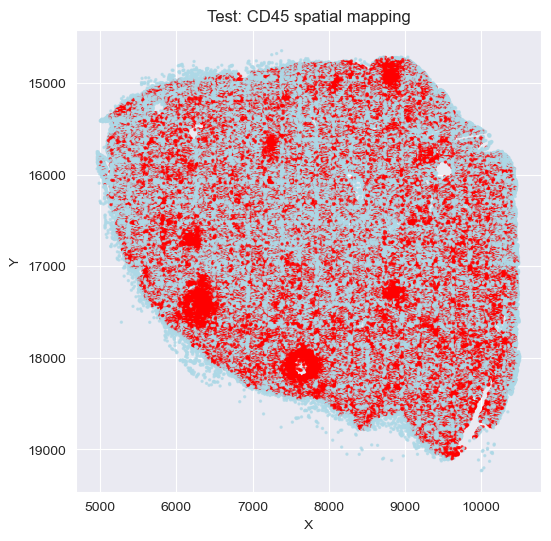

In [111]:
from scripts.spatialmapping import plot_spatial_marker

# One marker, here CD45+ vs CD45-
plot_spatial_marker(adata, "CD45", thresholded=True, title_prefix="Test: ", color_hi="red", color_lo="lightblue")

# Manual cell type annotation

In [110]:
from scripts.celltype_rules import assign_cell_types

# Annotate all cells
adata = assign_cell_types(adata)

/Users/magnusberg/Documents/Internships/fall 2025/IHOPE_SpatialProteomics/scripts/celltype_rules.py:62: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['branch'] = 'Unclassified_branch'


Dropped cells (no CD45 info): 0
CD45+ (Immune): 77090
CD45- (Non-Immune): 110007
T-cells: 27006
B-cells: 20398
Myeloid: 2950
Immune_Unclassified: 26897
Endothelial: 65236
Stromal: 13244
Non-Immune_Unclassified: 34640
T-cell subtypes summary:
    Treg: 1
    TfH_like: 7
    Th17_like: 17
    CD4_T: 3040
    CD8_T: 16170
    Stem_like_memory_T: 0
    Naive_T: 1237
    Tissue_Resident_T: 6295
    T_Unclassified: 239
B-cell subtypes summary:
    Memory_B: 10407
    Plasma_like: 194
    GC_like_B: 428
    Follicular_like_B: 972
    Activated_B: 4504
    B_Unclassified: 3732
Myeloid/APC subtypes summary:
    Monocyte/Macrophage: 2593
    cDC1: 176
    cDC2: 7
    Myeloid_Unclassified: 174
Non-immune subtypes summary:
    Endothelial: 1049
    Lymphatic_Endothelial: 41889
    Fibroblast: 4725
    FDC: 117
    Stromal_Unclassified: 43205
    Basement Membrane: 19022


** Spatial cell type visualization** 

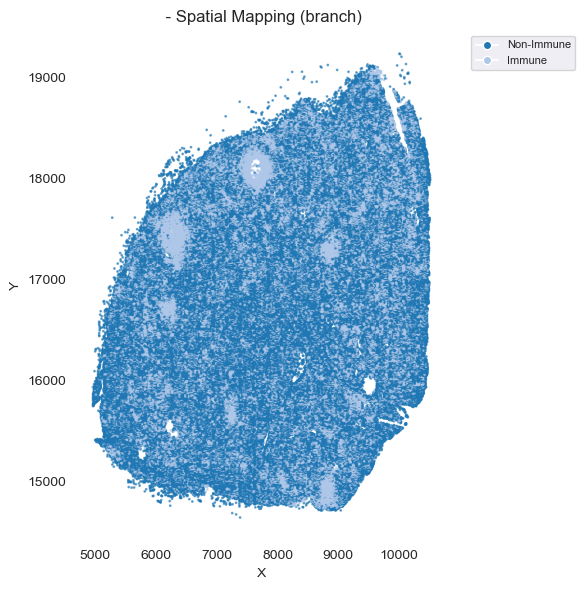

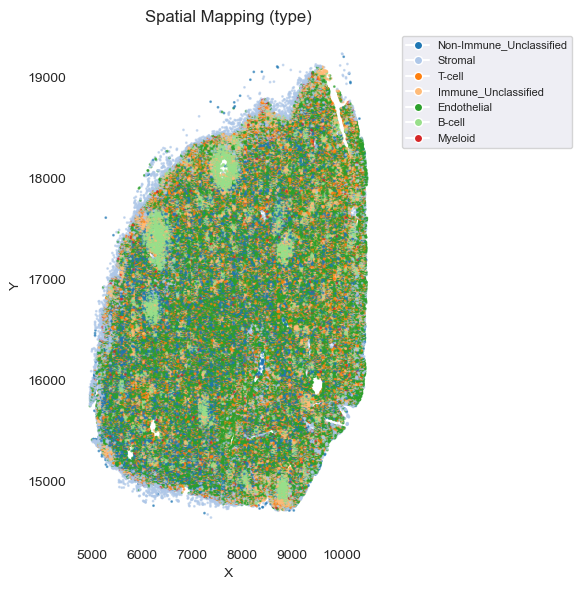

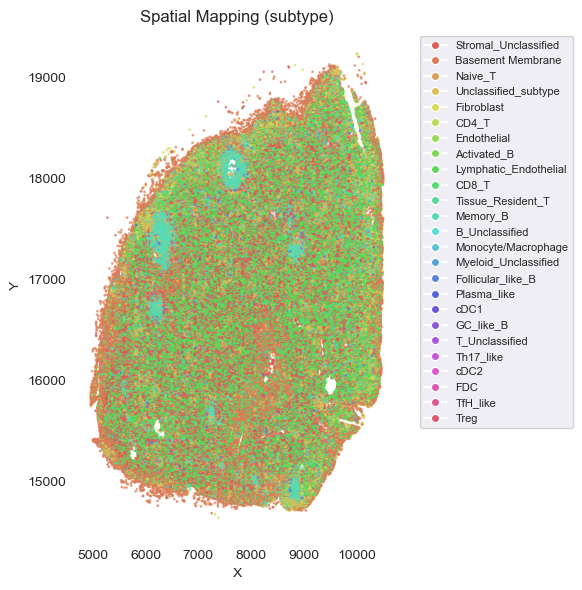

In [113]:
from scripts.spatialmapping import plot_spatial_cell_types

# Plot the branch level (immune/non-immune)
fig = plot_spatial_cell_types(
    adata,
    level="branch",
    size=1,
    alpha=0.6,
    invert_y=False,
    title_prefix=f" - ",
    save = False
)

# Plot the cell type level
fig_type = plot_spatial_cell_types(
    adata,
    level="type",
    size=1,
    alpha=0.6,
    invert_y=False,
    save = False
)

# Plot the cell subtype level
fig_subtype = plot_spatial_cell_types(
    adata,
    level="subtype",
    size=1,
    alpha=0.6,
    invert_y=False,
    save = False
)

**You can plot selected cell types/subtypes to avoid cluttering the spatial plots. Use the names seen here:**

**Cell types:**

'Endothelial', 'Stromal', 'Non-Immune_Unclassified'
'T-cell', 'B-cell', 'Myeloid', 'Immune_Unclassified'

**Cell subtypes:**

'Endothelial', 'Lymphatic_Endothelial', 'Fibroblast', 'FDC', 'Stromal_Unclassified', 'Basement Membrane'
'Monocyte/Macrophage', 'cDC1', 'cDC2', 'Myeloid_Unclassified'
'Memory_B', 'Plasma_like', 'GC_like_B', 'Follicular_like_B', 'Activated_B', 'B_Unclassified'
'Treg', 'TfH_like', 'Th17_like', 'CD4_T', 'CD8_T', 'Stem_like_memory_T', 'Naive_T', 'Tissue_Resident_T', 'T_Unclassified'

Saved to /Users/magnusberg/Documents/Internships/fall 2025/IHOPE_SpatialProteomics/results/figures/spatial_subset_type.png


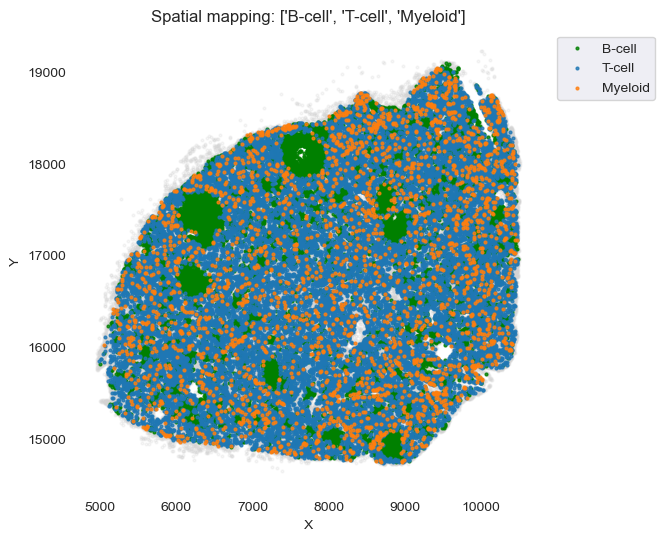

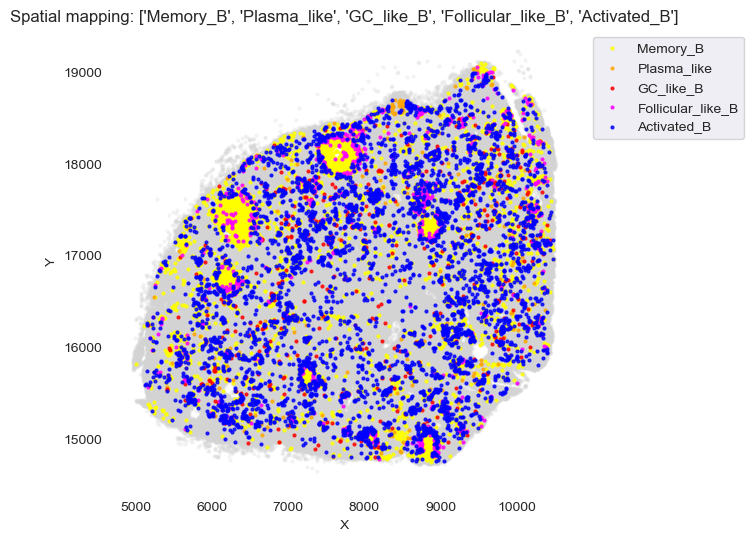

In [112]:
from scripts.spatialmapping import plot_spatial_subset

plot_spatial_subset(
    adata,
    level="type",
    include=["B-cell", "T-cell", "Myeloid"],
    colors={"B-cell": "green"},
    save = True
)

plot_spatial_subset(
    adata,
    level="subtype",
    include=["Memory_B", "Plasma_like", "GC_like_B", "Follicular_like_B", "Activated_B"],
    colors={"Memory_B": "yellow", "Plasma_like": "orange", "GC_like_B": "red", "Follicular_like_B": "magenta", "Activated_B": "blue"},
    save = False
)

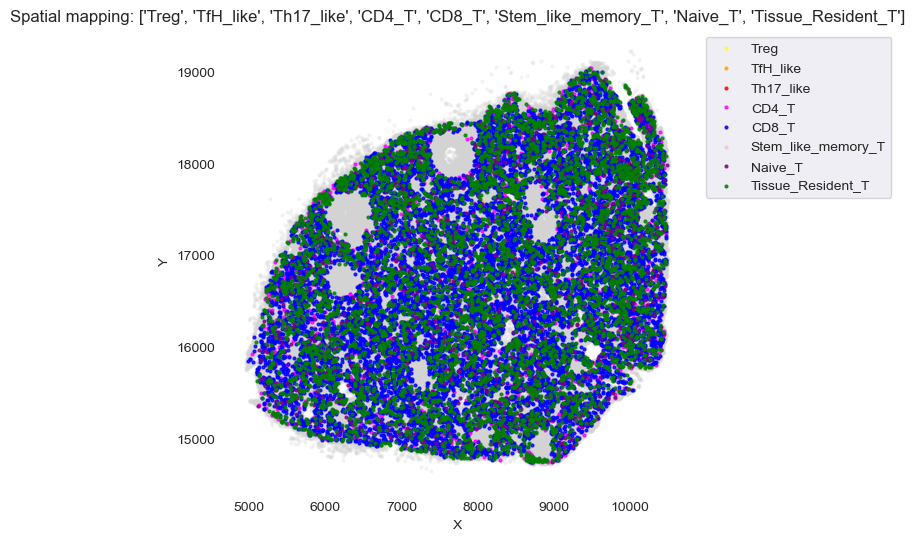

In [114]:
plot_spatial_subset(
    adata,
    level="subtype",
    include=['Treg', 'TfH_like', 'Th17_like', 'CD4_T', 'CD8_T', 'Stem_like_memory_T', 'Naive_T', 'Tissue_Resident_T'],
    colors={"Treg": "yellow", "TfH_like": "orange", "Th17_like": "red", "CD4_T": "magenta", "CD8_T": "blue", "Stem_like_memory_T": "pink", "Naive_T": "purple", "Tissue_Resident_T": "green"},
    save = False
)

# Clustering with PCA + Leiden + UMAP
Adapted from Natthaphong Kaewkam 2025

In [99]:
# If you need to load the anndata file:
adata = anndata.read_h5ad("../data/processed/anndata/banksy_adadata_backup_IHOPE26.h5ad")

In [100]:
print("adata.obs columns: ")
print(list(adata.obs.columns))


adata.obs columns: 
['Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'raw_CCR6_pos', 'raw_CCR7_pos', 'raw_CD107a_pos', 'raw_CD11c_pos', 'raw_CD14_pos', 'raw_CD141_pos', 'raw_CD163_pos', 'raw_CD1c_pos', 'raw_CD20_pos', 'raw_CD21_pos', 'raw_CD27_pos', 'raw_CD31_pos', 'raw_CD34_pos', 'raw_CD38_pos', 'raw_CD3e_pos', 'raw_CD4_pos', 'raw_CD40_pos', 'raw_CD45_pos', 'raw_CD45RA_pos', 'raw_CD45RO_pos', 'raw_CD57_pos', 'raw_CD68_pos', 'raw_CD69_pos', 'raw_CD79a_pos', 'raw_CD8_pos', 'raw_Collagen IV_pos', 'raw_CXCL13_pos', 'raw_DAPI_pos', 'raw_FOXP3_pos', 'raw_Granzyme B_pos', 'raw_HLA-DR_pos', 'raw_ICOS_pos', 'raw_IFNG_pos', 'raw_Ki67_pos', 'raw_LYVE1_pos', 'raw_PD-1_pos', 'raw_TCF-1_pos', 'raw_Vimentin_pos', 'banksy_domain', 'branch', 'type', 'subtype', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 

In [101]:
print("adata.obsm keys: ")
print(list(adata.obsm.keys()))

adata.obsm keys: 
['spatial']


In [10]:
print("adata.uns keys: ")
print(list(adata.uns.keys()))

adata.uns keys: 
['banksy_domain_colors', 'dendrogram_banksy_domain', 'normalization', 'rank_genes_groups', 'sample_id', 'thresholds', 'pca', 'neighbors', 'umap', 'leiden']


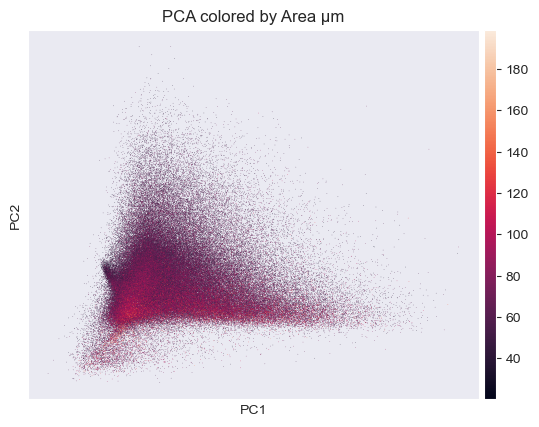

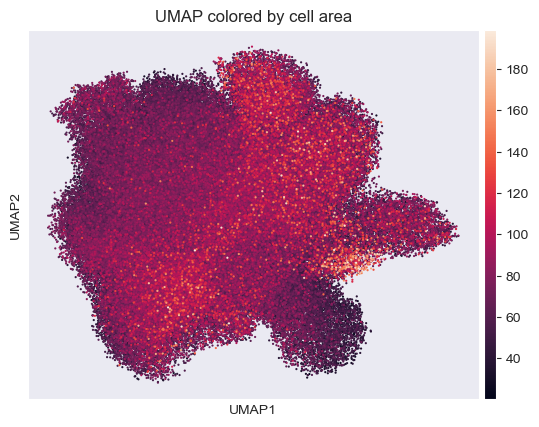

In [97]:
# Compute principal components for dimensionality reduction
sc.tl.pca(adata)

# Visualize PCA colored by cell area
sc.pl.pca(adata, color='Area µm^2', title='PCA colored by Area µm')

# Construct k-nearest neighbor graph using PCA representation
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

# Compute UMAP embedding for nonlinear dimensionality reduction
sc.tl.umap(adata, min_dist=0.5, spread=0.3)

# Perform Leiden clustering on the neighbor graph
# adata.obs['leiden'] will contain the Leiden clusters
sc.tl.leiden(adata, resolution=0.5)

# Visualize UMAP colored by cell area
sc.pl.umap(adata, color='Area µm^2', title='UMAP colored by cell area', size=10)

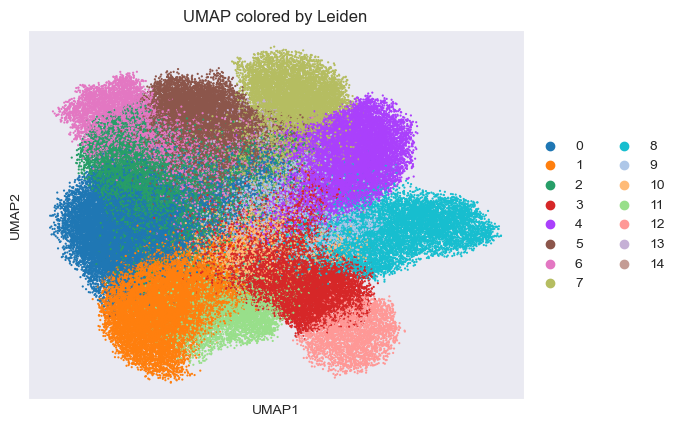

In [98]:
# And colored by Leiden cluster
sc.pl.umap(adata, color='leiden', title='UMAP colored by Leiden', size=10)

Heatmap

In [ ]:
# Recompute per-cluster means from the updated `adata`
if 'leiden' not in adata.obs:
    raise ValueError("Missing 'leiden' in adata.obs. Re-run clustering before plotting.")

# Ensure string labels and build expression DataFrame
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
expr_df = pd.DataFrame(np.asarray(adata.X), columns=adata.var_names, index=adata.obs_names)
expr_df['leiden'] = adata.obs['leiden'].values

# Mean expression per cluster
scaled_means_df = expr_df.groupby('leiden').mean()

# Optional: sort clusters numerically if labels are numeric strings
try:
    scaled_means_df = scaled_means_df.sort_index(key=lambda x: pd.to_numeric(x))
except Exception:
    pass

# Re-plot the heatmap with numeric annotations
clustergrid = sns.clustermap(
    scaled_means_df,
    cmap='coolwarm',
    linewidths=0.75,
    standard_scale=1,   # scale each row (cluster) for visualization
    figsize=(15, 10), # Use capped figure size
    annot=True,
    fmt=".2f",
    dendrogram_ratio=(0.2, 0.2)
)
clustergrid.fig.suptitle('Mean Expression per Leiden Cluster (Numeric Annotations)', y=1.03)
plt.setp(clustergrid.ax_heatmap.get_xticklabels(), rotation=90)
plt.show()

# --- Extract and display the numerical data from the heatmap ---
print("\n--- Numerical Data from Heatmap ---")
# The clustermap reorders the rows and columns. We can get this new order.
reordered_row_indices = clustergrid.dendrogram_row.reordered_ind
reordered_col_indices = clustergrid.dendrogram_col.reordered_ind

# Get the reordered labels from the original DataFrame
reordered_rows = scaled_means_df.index[reordered_row_indices]
reordered_cols = scaled_means_df.columns[reordered_col_indices]

# The `data2d` attribute holds the scaled and reordered numerical data
heatmap_data = clustergrid.data2d

# Create a new DataFrame with the reordered data and labels
reordered_df = pd.DataFrame(heatmap_data, index=reordered_rows, columns=reordered_cols)

print("The following table shows the scaled and clustered data as seen in the heatmap:")
print(reordered_df)

# Export the numerical data to a CSV file
output_csv_path = '../data/processed/IHOPE26_LN_heatmap_numerical_data.csv'
reordered_df.to_csv(output_csv_path)
print(f"\nNumerical data from the heatmap has been exported to '{output_csv_path}'")

In [19]:
# Get and display cell counts per cluster
print("\nCell Counts per Cluster: ")
# Use value_counts() to get the number of cells in each cluster
# Sort by index
cluster_counts = adata.obs['leiden'].value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='ignore'))
print("The following table shows the number of cells in each cluster:")
print(cluster_counts.to_string())


--- Cell Counts per Cluster ---
The following table shows the number of cells in each cluster:
leiden
0     26185
1     24729
2     22272
3     21720
4     20450
5     14538
6     11520
7     11133
8     10120
9      8704
10     6785
11     4990
12     2953
13      842
14      156


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/2971441731.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  cluster_counts = adata.obs['leiden'].value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='ignore'))


Spatial visualization of clusters


--- Plotting spatial distribution of clusters ---


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1746251312.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,


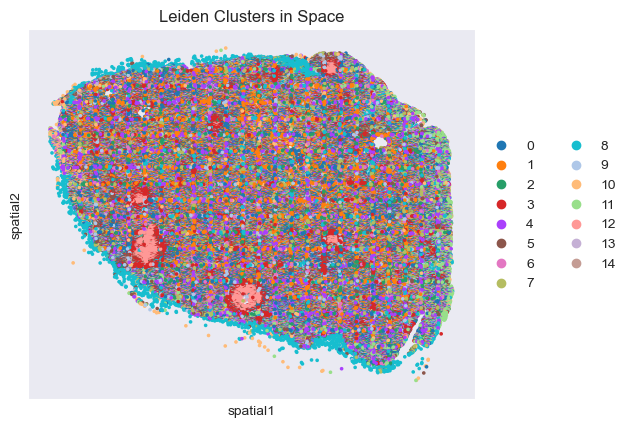


Simplified cluster characterization complete.


In [20]:
print("\nPlotting spatial distribution of clusters... ")
if 'spatial' in adata.obsm and 'leiden' in adata.obs.columns:
    spatial_colors = ['leiden']
    # Add annotated types
    if 'cell_type_annotation' in adata.obs.columns:
        spatial_colors.append('cell_type_annotation')

    sc.pl.spatial(adata,
                  color=spatial_colors,
                  spot_size=50, # Adjust spot_size
                  title=['Leiden Clusters in Space', 'Annotated Types in Space'][:len(spatial_colors)])
else:
    print("Skipping spatial plot ('spatial' coords or 'leiden' column missing).")

print("\nSimplified cluster characterization complete.")

Save anndata object with PCA, neighbors, UMAP, and Leiden clusters if you're content:

In [15]:
adata.write_h5ad("../data/processed/anndata/IHOPE26_adata_with_leiden_banksy_GMM_raw.h5ad")

You can now load the data anytime:

In [102]:
# If you need to load the anndata file:
adata = anndata.read_h5ad("../data/processed/anndata/IHOPE26_adata_with_leiden_banksy_GMM_raw.h5ad")

**Exploring specific markers and clusters**

See names below:

In [103]:
print(adata.var_names)

Index(['raw_CCR6', 'raw_CCR7', 'raw_CD107a', 'raw_CD11c', 'raw_CD14', 'raw_CD141', 'raw_CD163', 'raw_CD1c', 'raw_CD20', 'raw_CD21', 'raw_CD27', 'raw_CD31', 'raw_CD34', 'raw_CD38', 'raw_CD3e', 'raw_CD4', 'raw_CD40', 'raw_CD45', 'raw_CD45RA', 'raw_CD45RO', 'raw_CD57', 'raw_CD68', 'raw_CD69', 'raw_CD79a', 'raw_CD8', 'raw_Collagen IV', 'raw_CXCL13', 'raw_DAPI', 'raw_FOXP3', 'raw_Granzyme B', 'raw_HLA-DR', 'raw_ICOS', 'raw_IFNG', 'raw_Ki67', 'raw_LYVE1', 'raw_PD-1', 'raw_TCF-1', 'raw_Vimentin'], dtype='object')


Violin plot of marker distribution in clusters

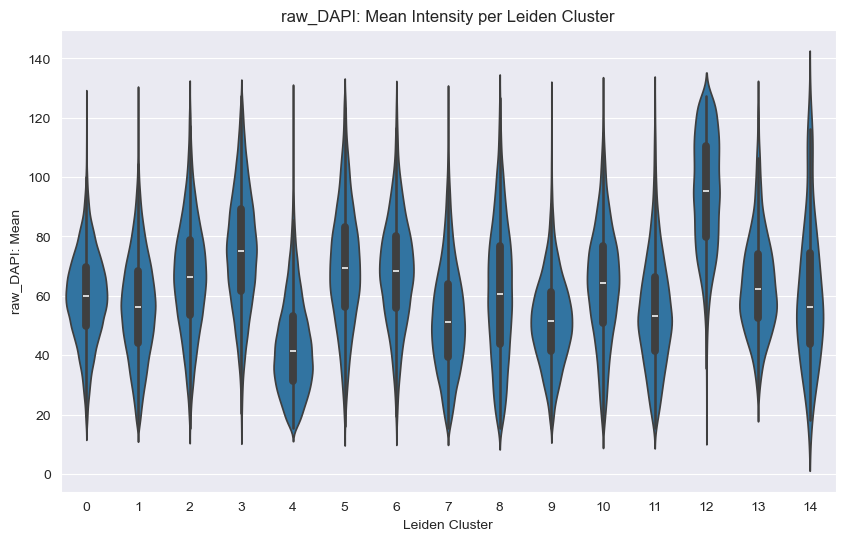

In [104]:
# Marker to assess across Leiden clusters
marker = 'raw_DAPI'

# Proceed only if the marker is present in the feature table
if marker in adata.var_names:
    # Extract per-cell DAPI intensity values
    marker_values = adata[:, marker].X.flatten()

    # Use Leiden assignments as grouping variable
    clusters = adata.obs['leiden']

    # Assemble expression and cluster labels for downstream visualization
    df_violin = pd.DataFrame({marker: marker_values, 'leiden': clusters})

    plt.figure(figsize=(10, 6))

    # Compare marker intensity distributions across clusters
    sns.violinplot(x='leiden', y=marker, data=df_violin, inner='box')

    plt.title(f'{marker}: Mean Intensity per Leiden Cluster')
    plt.xlabel('Leiden Cluster')
    plt.ylabel(f'{marker}: Mean')
    plt.show()
else:
    print(f"{marker} not found in adata.var_names.")


Violin plot of cell area in clusters

In [ ]:
sc.pl.violin(adata, ['Area µm^2'], groupby='leiden', rotation=90)
plt.title('Distribution of Cell Area per Leiden Cluster')
plt.show()

Spatial distribution of selected clusters

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/3891438656.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_subset, color='leiden', spot_size=50, title='Spatial Distribution of Selected Clusters')
/Users/magnusberg/.miniconda3/envs/ihopespatial/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


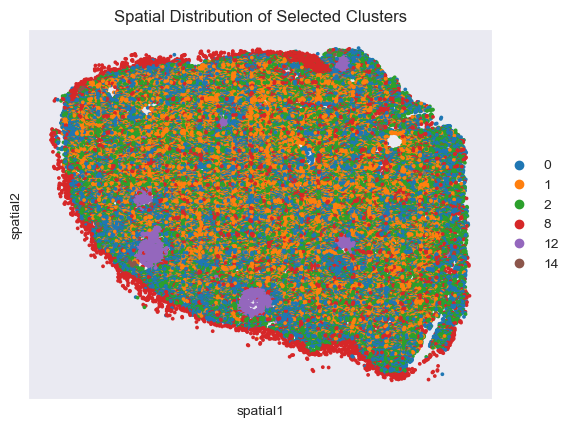

In [105]:
# Specify clusters to plot
clusters_to_plot = ['2', '0', '12', '1', '8', '14']

# Filter the anndata object for the desired clusters
adata_subset = adata[adata.obs['leiden'].isin(clusters_to_plot)]

# Plot the spatial distribution for the filtered clusters
sc.pl.spatial(adata_subset, color='leiden', spot_size=50, title='Spatial Distribution of Selected Clusters')

**Cluster annotation**

Adds:

adata.obs['celltype_major'] → major lineage annotation for each cell

adata.obs['celltype_fine'] → fine-grained subtype annotation

By comparing the intensities of individual markers within clusters, you can assign cell type identities to the clusters. This requires knowledge of cell types and canonical immunology markers. You could just visually inspect the heatmap. A more stringent option is to assign percentile-based marker positivity. It is also important to consider that the clustering parameters and input data will change the cluster contents. This is just one example of a workflow.

**Visual method**

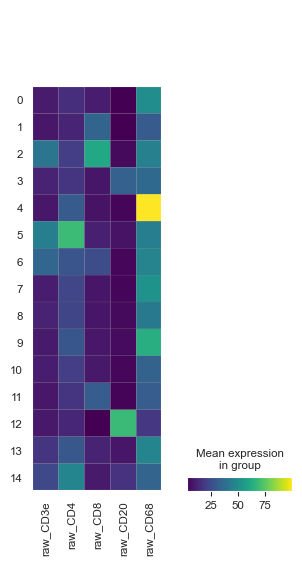

In [32]:
# Choose markers of interest
markers = ['raw_CD3e', 'raw_CD4', 'raw_CD8', 'raw_CD20', 'raw_CD68']

sc.pl.matrixplot(adata, var_names=markers, groupby='leiden', cmap='viridis')


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1153473336.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_subset, color='leiden', spot_size=50, title='Spatial Distribution of Selected Clusters')


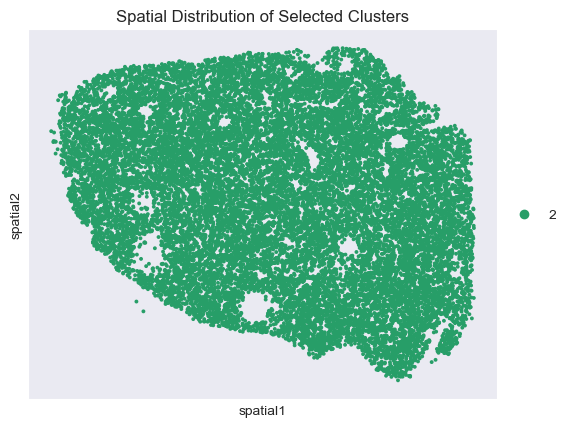

In [45]:
# Specify cluster to plot
cluster_to_plot = ['2']

# Filter the anndata object for the desired clusters
adata_subset = adata[adata.obs['leiden'].isin(cluster_to_plot)]

# Plot the spatial distribution for the filtered clusters
sc.pl.spatial(adata_subset, color='leiden', spot_size=50, title='Spatial Distribution of Selected Clusters')

In [43]:
from scripts.cluster_annotation import summarize_single_cluster
top_markers_0 = summarize_single_cluster(adata, cluster_id='0')
print(top_markers_0)


raw_CD45RO      64.474064
raw_DAPI        59.630170
raw_CD68        50.344980
raw_Vimentin    25.365653
raw_CD45        23.640049
raw_CD163       20.353042
raw_CD107a      18.035067
raw_CD4         15.828963
raw_CD141       15.237732
raw_TCF-1       15.157227
dtype: float64


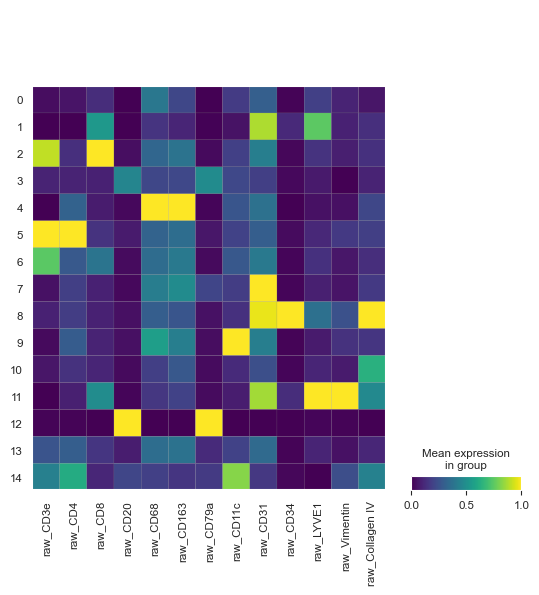

In [47]:
# Choose a set of key markers (or all)
markers_of_interest = ['raw_CD3e','raw_CD4','raw_CD8','raw_CD20','raw_CD68','raw_CD163', 'raw_CD79a', 'raw_CD11c', 'raw_CD31', 'raw_CD34', 'raw_LYVE1', 'raw_Vimentin', 'raw_Collagen IV']

# Matrix plot: average expression per cluster
sc.pl.matrixplot(
    adata,
    var_names=markers_of_interest,
    groupby='leiden',
    cmap='viridis',
    standard_scale='var'  # scales each marker across clusters to 0–1
)


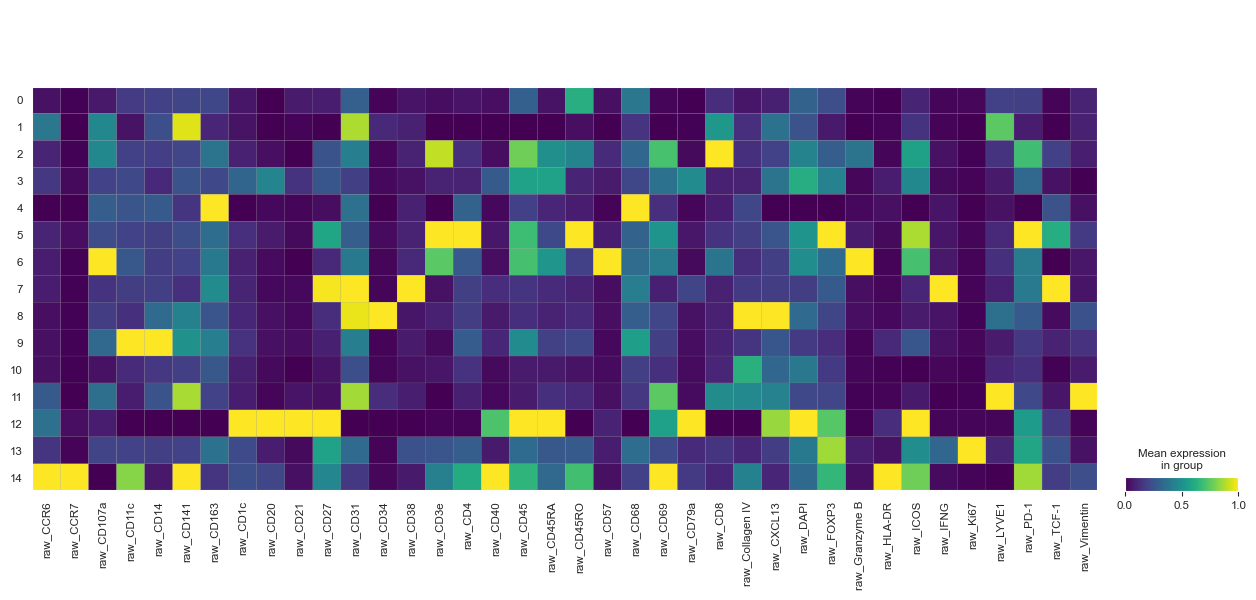

In [48]:
# All markeres

# Matrix plot: average expression per cluster
sc.pl.matrixplot(
    adata,
    var_names=adata.var_names,
    groupby='leiden',
    cmap='viridis',
    standard_scale='var'  # scales each marker across clusters to 0–1
)


**Summary**

0: Positive: CD45RO. Negative: most others. Ambiguous: CD45, CD68

Suggestion: T-cell, potential memory/atypical/noise as it lacks CD3e.

1: Positive: CD141, CD31, LYVE1, Slightly positive: CD107a, 8. Ambiguous: CXCL13. Negative: most others

Suggestion: Stromal, lymphatic endothelial (examine CXCL13, possible follicular microenvironment influence)

2: Positive: CD8, CD3e, CD69, CD45, PD-1. Negative: CD79a, CD20, CD21, CCR7, HLA-DR, Ki67. Ambiguous: CD107a, CD45RA, CD45RO

Suggestion: T-cell, CD8 resident/activated.
Notes: non-cytotoxic with PD-1 positivity

3: Positive: CD45 (pan-leukocyte), CD45RA, ICOS. Negative: CCR7, CD34, Granzyme B, IFNG, Ki67, TCF-1, Vimentin. Ambiguous: CD107a

Suggestion: T-cell atypical (CD3e negative) Tfh / activated CD4 (lacking CD4...)
Notes: CD3e dropout, CD45RA+ CD45RO− pattern unusual, may be early activated or noise

4: Positive: CD163, CD68. Ambiguous: CD31. Negative: everything else

Suggestion: Myeloid, macrophages.
Notes: CD163+ CD68+; non-cytotoxic, tissue-resident

5: Positive: CD3e, CD4, CD45, CD45RO, FOXP3, PD-1, ICOS, CD27. Negative: CD21, CCR7, CD34, HLA-DR, Ki67

Suggestion: T-cell, Treg?
Notes: FOXP3+ memory phenotype, PD-1/ICOS+ suppressive lineage.

6: Positive: CD107a, CD57, Granzyme B, ICOS, CD45, CD3e. Negative: CCR7, CD20, CD21, CD34, CD40, CD79a, HLA-DR. Ambiguous: CD31

Suggestion: T-cell, cytotoxic effector (but lacking CD8...?)
Notes: terminally differentiated CD57+, Granzyme B+, CD8 should be present

7: Positive: CD27, CD31, CD38, IFNG, TCF-1. Negative: CCR7, CD21, CD20, CD34, Ki67, CD3e, CD57, CD69, CD8, Granzyme B, HLA-DR, LYVE-1, Vimentin. Ambiguous: PD-1

Suggestion: T-cell, atypical (lacks CD3e) but Th1-like (IFNG without Granzyme B, TCF-1 presence)
Look up TCF-1⁺ IFNG⁺ “stem-like” or progenitor-effector T cells.
Notes: Progenitor-like/stem-like Th1 T cells, TCF-1+ IFNG+, non-cytotoxic, CD3e dropout.

8: Positive: CD34, CD31, Collagen IV, CXCL13. Negative: CCR6, CCR7, CD21, CD20, CD38, CD40, CD57, CD79a, Granzyme B, HLA-DR, Ki67, TCF-1. Ambiguous: CD141, CD14.

Suggestion: Stromal, FDC (CXCL13) or just stromal.
Notes: Non-hematopoietic stromal organizer cells of germinal centers, CXCL13+ Collagen IV+ CD31+, non-hematopoietic

9: Positive: CD11c, CD14. Negative: CCR6, CCR7, CD20, CD21, CD34, CD3e, CD57, CD79a, Granzyme B, Ki67, IFNG. Ambiguous: CD31, CD141, CD45, CD68.

Suggestion: Myeloid, antigen-presenting/monocyte-like.
Notes: Non-cytotoxic, non-proliferative myeloid cells, maybe monocyte-derived APCs

10: Positive: Collagen (weak). Negative: all other markers.

Suggestion: Stromal, acellular collagenous regions.

11: Positive: LYVE1, Vimentin, CD69 (low), CD31, CD141. Ambiguous: CD107a, CD8, Collagen IV, CXCL13. Negative: all other markers.

Suggestion: Stromal/endothelial, lymphatic endothelial.
Notes: Non-hematopoietic stromal cells; likely lymphatic vessels or sinus-lining cells

12: Positive: CD11c, CD20, CD21, CD27, CD45, CD45RA, CD79a, DAPI, ICOS, FOXP3 (low), CXCL13 (low). Negative: Vimentin, LYVE1, Ki67, IFNG, Granzyme B, Collagen IV, CD8, CD68, CD45RO, CD4, and almost everything else. Ambiguous: PD-1.

Suggestion: B-cells, naive/resting. Low FOXP3/ICOS/CXCL13 probably from follicular microenvironment (subclusters??)
Notes: Low FOXP3/ICOS/CXCL13 likely reflects follicular microenvironment; predominantly naive B phenotype

13: Positive: Ki67, FOXP3. Negative: CCR7, CD21, CD20, CD34, CD40, Granzyme B, HLA-DR, Vimentin. Ambiguous: ICOS, PD-1, CD27. Note: very low CD3e.

Suggestion: T-cells, proliferating regulatory.
Notes: Ambiguous ICOS/PD-1/CD27 indicate activated/memory-like Treg features; low CD3e noise?

14: Positive: CCR6, CCR7, CD141, CD40, CD69, HLA-DR, ICOS, PD-1, CD45RO, CD4, CD11c. Negative: CD107a, CD14, CD21, CD34, CD38, CD57, Granzyme B, IFNG, Ki67, LYVE-1. Ambiguous: CD3e, CD27.

Suggestion: T-cells, activated memory CD4.
Notes: CCR6+ CCR7+ indicates lymph node homing; HLA-DR, ICOS, PD-1, CD69 indicate activation; CD11c/CD141 likely reflect APC interaction rather than myeloid identity

**Percentile-based method**

In [95]:
# Compute the mean expression per cluster
cluster_means = adata.to_df().groupby(adata.obs['leiden']).mean()

# Compute thresholds for each marker
# Option 1: 70th percentile per marker across clusters (like your colleague)
thresholds = cluster_means.quantile(0.7, axis=0)

# Build a binary matrix of positive markers
positive_matrix = cluster_means.ge(thresholds)

# Print positive markers per cluster
for cluster in positive_matrix.index:
    positives = positive_matrix.columns[positive_matrix.loc[cluster]].tolist()
    print(f"Cluster {cluster}: {positives}")

# Optional: view the binary matrix as a DataFrame
positive_matrix


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1215868130.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = adata.to_df().groupby(adata.obs['leiden']).mean()


Cluster 0: ['raw_CD21', 'raw_CD45RO', 'raw_CD68', 'raw_Ki67', 'raw_LYVE1']
Cluster 1: ['raw_CCR6', 'raw_CD107a', 'raw_CD14', 'raw_CD141', 'raw_CD31', 'raw_CD34', 'raw_CD8', 'raw_CXCL13', 'raw_LYVE1']
Cluster 2: ['raw_CD107a', 'raw_CD163', 'raw_CD31', 'raw_CD38', 'raw_CD3e', 'raw_CD45', 'raw_CD45RA', 'raw_CD45RO', 'raw_CD57', 'raw_CD69', 'raw_CD8', 'raw_DAPI', 'raw_Granzyme B', 'raw_ICOS', 'raw_LYVE1', 'raw_PD-1', 'raw_TCF-1']
Cluster 3: ['raw_CCR6', 'raw_CCR7', 'raw_CD11c', 'raw_CD1c', 'raw_CD20', 'raw_CD21', 'raw_CD34', 'raw_CD40', 'raw_CD45RA', 'raw_CD79a', 'raw_CXCL13', 'raw_DAPI', 'raw_FOXP3', 'raw_HLA-DR']
Cluster 4: ['raw_CD11c', 'raw_CD14', 'raw_CD163', 'raw_CD4', 'raw_CD68', 'raw_Collagen IV', 'raw_TCF-1']
Cluster 5: ['raw_CCR7', 'raw_CD20', 'raw_CD27', 'raw_CD34', 'raw_CD38', 'raw_CD3e', 'raw_CD4', 'raw_CD45', 'raw_CD45RO', 'raw_CD57', 'raw_CD69', 'raw_DAPI', 'raw_FOXP3', 'raw_Granzyme B', 'raw_ICOS', 'raw_IFNG', 'raw_Ki67', 'raw_PD-1', 'raw_TCF-1', 'raw_Vimentin']
Cluster 6: 

,raw_CCR6,raw_CCR7,raw_CD107a,raw_CD11c,raw_CD14,raw_CD141,raw_CD163,raw_CD1c,raw_CD20,raw_CD21,raw_CD27,raw_CD31,raw_CD34,raw_CD38,raw_CD3e,raw_CD4,raw_CD40,raw_CD45,raw_CD45RA,raw_CD45RO,raw_CD57,raw_CD68,raw_CD69,raw_CD79a,raw_CD8,raw_Collagen IV,raw_CXCL13,raw_DAPI,raw_FOXP3,raw_Granzyme B,raw_HLA-DR,raw_ICOS,raw_IFNG,raw_Ki67,raw_LYVE1,raw_PD-1,raw_TCF-1,raw_Vimentin
leiden,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
1,True,False,True,False,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False
2,False,False,True,False,False,False,True,False,False,False,False,True,False,True,True,False,False,True,True,True,True,False,True,False,True,False,False,True,False,True,False,True,False,False,True,True,True,False
3,True,True,False,True,False,False,False,True,True,True,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,True,True,True,False,True,False,False,False,False,False,False,False
4,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
5,False,True,False,False,False,False,False,False,True,False,True,False,True,True,True,True,False,True,False,True,True,False,True,False,False,False,False,True,True,True,False,True,True,True,False,True,True,True
6,False,False,True,True,False,False,True,False,False,False,False,False,False,True,True,False,False,True,True,False,True,False,False,False,True,False,False,True,False,True,False,True,True,False,False,False,False,False
7,False,False,False,False,False,False,True,False,False,False,True,True,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False
8,False,False,False,False,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,True


After assigning clusters with cell type identities, define and visualize:

In [82]:
# Major lineage palette (Adjust as desired)
major_palette = {
    'T cells'   : '#2171b5',
    'B cells'   : '#4daf4a',
    'Myeloid'   : '#ff7f00',
    'Stromal'   : '#984ea3',
    'Unassigned immune': '#999999'
}

# Fine cell type palette (SIMPLIFIED LABELS)
fine_palette = {
    # B lineage
    'GC B': '#006400',
    'Memory B': '#228b22',
    'Follicular/Mature B': '#66cdaa',
    'Activated B': '#98fb98',
    'B cells': '#32cd32',
    'Naive/resting B cells': '#00fa9a',

    # T lineage
    'Resident/activated T cell': '#8c2d04',
    'Unassigned immune/atypical T cell': '#66c2a5',
    'Treg': '#2c3e50',
    'Putative cytotoxic T cell': '#e41a1c',

    # Myeloid/DC
    'Monocyte/macrophage': '#FFA500',
    'APC': '#ffa500',
    'cDC2-like': '#ffd700',
    'cDC1-like': '#8b4513',

    # Stromal/FDC
    'Stromal fibroblast-like': '#4b0082',
    'Stromal FDC-like': '#8b008b',
    'Lymphatic endothelial': '#ff1493',
    'Collagenous ECM': '#7f7f7f',
    'Endothelial': '#ff4500',
    'Fibroblast/Stromal': '#ffd700',

    'Unassigned': '#999999'
}

# Map cluster -> major lineage
# This is dependent on your data and clustering
cluster_to_major = {
    '0': 'Unassigned immune', # Or atypical T cell
    '1': 'Stromal',
    '2': 'T cells',
    '3': 'Unassigned immune', # Or atypical T cell
    '4': 'Myeloid',
    '5': 'T cells',
    '6': 'T cells',
    '7': 'Unassigned immune', # Or atypical T cell
    '8': 'Stromal', #progenitor marker, fibroblast like, CXCL13 B attractant
    '9': 'Myeloid',
    '10': 'Stromal', #acellular?
    '11': 'Stromal',
    '12': 'B cells', #mature?
    '13': 'T cells', #treg but no CD3e or CD4?
    '14': 'Unassigned immune', #Contradiction DCs and TCs (activated)
}

# Map cluster -> fine cell type
cluster_to_fine = {
    '0':  'Unassigned immune/atypical T cell',
    '1':  'Lymphatic endothelial',
    '2':  'Resident/activated T cell',
    '3':  'Unassigned immune/atypical T cell',
    '4':  'Monocyte/macrophage',
    '5':  'Treg',
    '6':  'Putative cytotoxic T cell', #lacks CD8
    '7':  'Unassigned immune/atypical T cell',
    '8':  'Stromal fibroblast-like',
    '9':  'Monocyte/macrophage',
    '10': 'Collagenous ECM',
    '11': 'Lymphatic endothelial',
    '12': 'B cells', #Naive/resting ?
    '13': 'Unassigned immune/atypical T cell',
    '14': 'Unassigned immune/atypical T cell',
}

# Apply mappings to AnnData
adata.obs['leiden_celltype_major'] = adata.obs['leiden'].astype(str).map(cluster_to_major).fillna('Unassigned')
adata.obs['leiden_celltype_fine']  = adata.obs['leiden'].astype(str).map(cluster_to_fine).fillna('Unassigned')

# Check counts:
print(adata.obs['leiden_celltype_major'].value_counts())
print(adata.obs['leiden_celltype_fine'].value_counts())

leiden_celltype_major
Unassigned immune    59194
T cells              49172
Stromal              46624
Myeloid              29154
B cells               2953
Name: count, dtype: int64
leiden_celltype_fine
Unassigned immune/atypical T cell    60036
Lymphatic endothelial                29719
Monocyte/macrophage                  29154
Resident/activated T cell            22272
Treg                                 14538
Putative cytotoxic T cell            11520
Stromal fibroblast-like              10120
Collagenous ECM                       6785
B cells                               2953
Name: count, dtype: int64


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/2204478389.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden_celltype_major', title='IHOPE26 LN Major lineages',


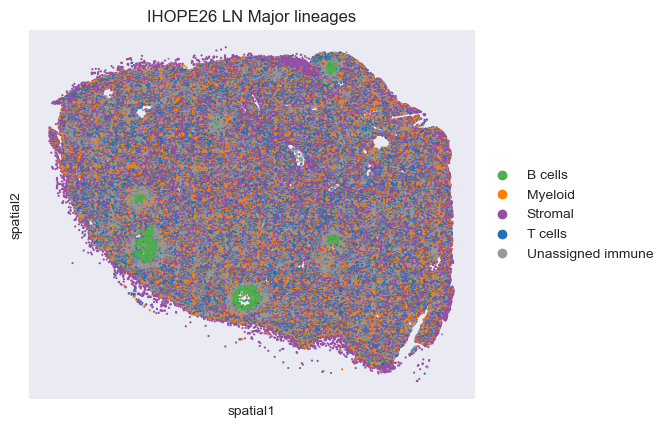

In [72]:
# Plot major cell types
sc.pl.spatial(adata, color='leiden_celltype_major', title='IHOPE26 LN Major lineages',
              spot_size=30, palette=major_palette)

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/2677375546.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden_celltype_fine',  title='IHOPE26 LN Finer cell types',


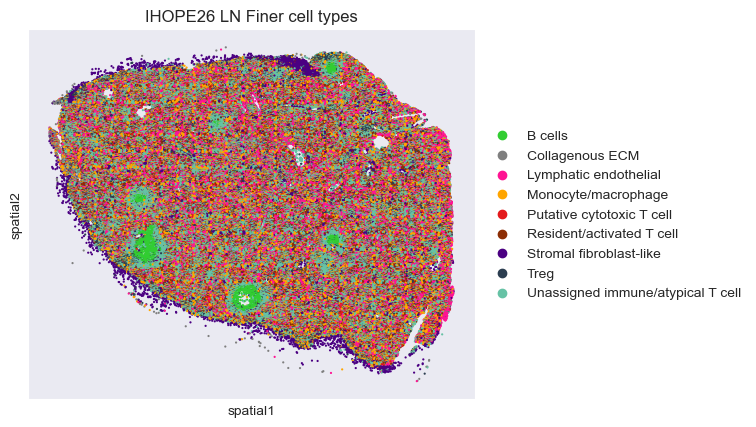

In [83]:
# Plot fine cell types
sc.pl.spatial(adata, color='leiden_celltype_fine',  title='IHOPE26 LN Finer cell types',
              legend_loc='right margin', spot_size=30, palette=fine_palette)


/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1665494645.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


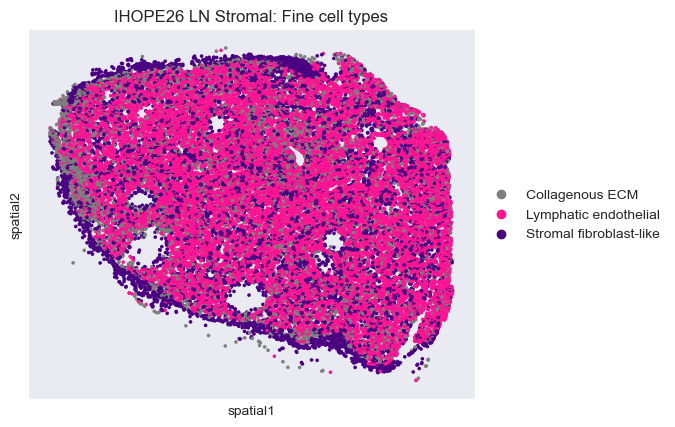

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1665494645.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


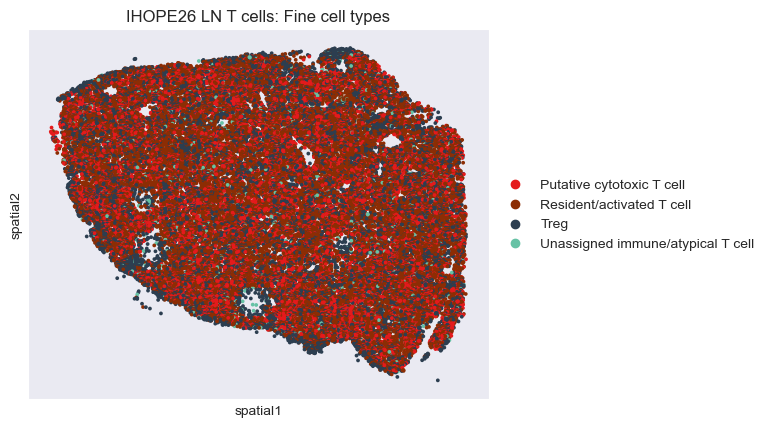

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1665494645.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


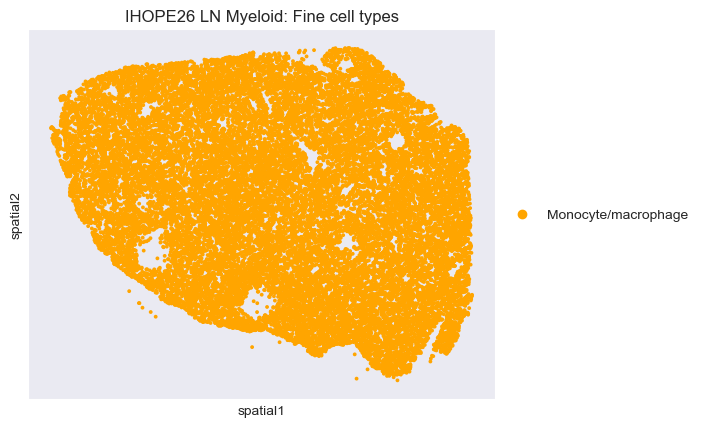

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1665494645.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


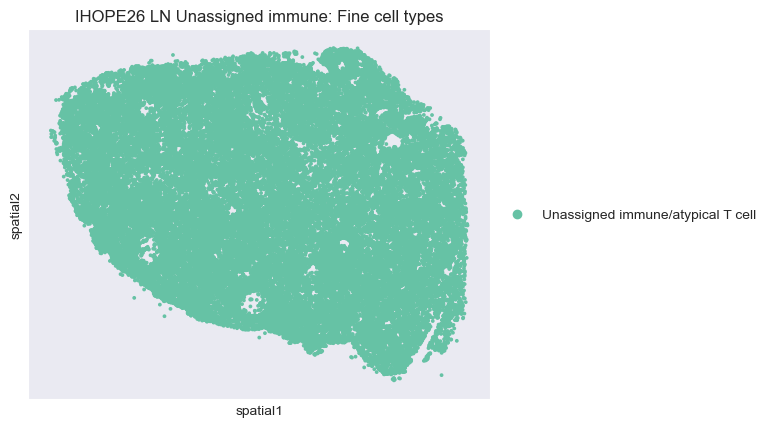

/var/folders/30/65bd79gx1xq3x7x5jng74jrh0000gn/T/ipykernel_96467/1665494645.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


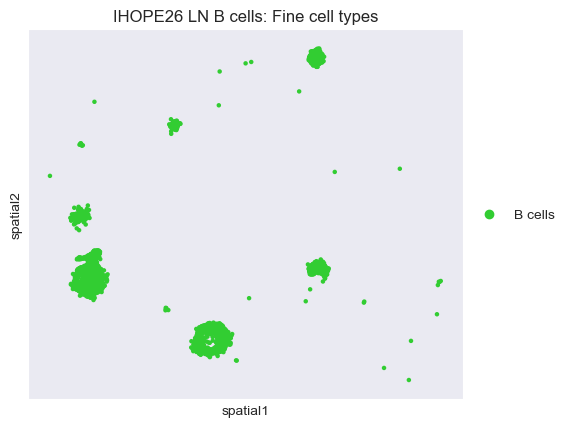

In [84]:
# Less cluttered plots for fine cell types:
# Get all major lineages
major_lineages = adata.obs['leiden_celltype_major'].unique()

# Loop over major lineages and plot fine types spatially within each
for major in adata.obs['leiden_celltype_major'].unique():
    # Subset to cells in this major lineage
    mask = adata.obs['leiden_celltype_major'] == major
    adata_sub = adata[mask].copy()

    # Plot using the full fine_palette
    sc.pl.spatial(
        adata_sub,
        color='leiden_celltype_fine',
        title=f'IHOPE26 LN {major}: Fine cell types',
        spot_size=30,
        palette=fine_palette,
        legend_loc='right margin'
    )



If good enough, save anndata for later:

In [85]:
adata.write("../data/processed/anndata/IHOPE26_RAW_all_annotations_revised1.h5ad")

# BANKSY!
For this part you need a saved .h5ad file containing an anndata object, and Python 12 is required (not Python 13). Note that BANKSY only identifies spatial domains and not cell types. This section provides the workflow from AnnData object to BANKSY domains, which can be used as a foundation for further analysis.

In [ ]:
from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam

h5ad_file = "../data/processed/anndata/IHOPE26_LN_InstanSeq_filtered_outliers_TEST_RAW.h5ad"

# Load your spatial transcriptomics data
adata_BANKSY = sc.read_h5ad(h5ad_file)

# Initialize BANKSY
coord_keys = ('x', 'y', 'spatial')
banksy_dict = initialize_banksy(
    adata_BANKSY,
    coord_keys=coord_keys,
    num_neighbours=15,
    nbr_weight_decay='scaled_gaussian'
)

# Run BANKSY clustering

results_df = run_banksy_multiparam(
    adata_BANKSY,
    banksy_dict,
    lambda_list=[0.2],
    resolutions=[0.5, 1.0]
)

In [ ]:
# This should be the new version!
from banksy.main import median_dist_to_nearest_neighbour
from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix
from banksy_utils.umap_pca import pca_umap
from banksy.cluster_methods import run_Leiden_partition
from banksy.plot_banksy import plot_results

# Parameters for BANKSY
coord_keys = ('x', 'y', 'spatial')
k_geom = 15
max_m = 1
nbr_weight_decay = "scaled_gaussian"
lambda_list = [0.8]
resolutions = [0.5]       # Leiden clustering resolution
pca_dims = [20]             # Try a lower number?
cluster_algorithm = 'leiden'
cmap = 'tab20'             # color map for spatial plotting
save_path = None           # e.g., "./BANKSY_results" if you want to save figures

# Compute neighbor distances
nbrs = median_dist_to_nearest_neighbour(adata, key=coord_keys[2])

# Initialize BANKSY
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=False,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=False
)

# Generate BANKSY matrix
banksy_dict, banksy_matrix = generate_banksy_matrix(
    adata,
    banksy_dict,
    lambda_list,
    max_m
)

# Dimensionality reduction by UMAP
pca_umap(
    banksy_dict,
    pca_dims=pca_dims,
    add_umap=True
)

# Run Leiden clustering
results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions=resolutions,
    num_nn=50,
    num_iterations=-1,
    partition_seed=1234,
    match_labels=True,
    max_labels=None
)

# Map clusters back to adata
cluster_labels = results_df.labels[results_df.index[0]].dense
adata.obs['banksy_domain'] = cluster_labels.astype(str)

# Optional: visualize
sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')

# Optional: use BANKSY plotting function
if save_path is not None:
    os.makedirs(save_path, exist_ok=True)
    weights_graph = banksy_dict['scaled_gaussian']['weights'][1]
    plot_results(
        results_df[results_df['num_labels']==len(np.unique(cluster_labels))],
        weights_graph,
        cmap,
        match_labels=True,
        coord_keys=coord_keys,
        max_num_labels=max_num_labels,
        save_path=save_path,
        save_fig=True,
        save_fullfig=True,
        dataset_name='Sample',
        save_labels=True
    )

print("BANKSY clustering complete! Domains added to `adata.obs['banksy_domain']`")

In [ ]:
# Deciphering cluster identity!

cluster_key = "banksy_domain"

# Clusterwise mean intensity heatmap:
#Mean expression per domain
cluster_means = (
    pd.DataFrame(
        adata.X,
        index=adata.obs_names,
        columns=adata.var_names
    )
    .groupby(adata.obs[cluster_key])
    .mean()
)

# Z-score across clusters
cluster_means_z = cluster_means.sub(cluster_means.mean(), axis=1)
cluster_means_z = cluster_means_z.div(cluster_means.std(), axis=1)

#Heatmap z-scored
sns.clustermap(
    cluster_means_z,
    cmap="vlag",
    center=0,
    figsize=(10, 12),
    col_cluster=True,
    row_cluster=True
)
plt.suptitle("BANKSY domains marker enrichment z-scored", y=1.02)
plt.show()

# Rows = BANKSY domains
# Columns = markers
# Red = enriched, Blue = depleted
# GC domains should light up for CD20, CD21, CD38, CXCL13
# T zones for CD3e, CD4, CD8
# Sinus / stroma for LYVE1, Vimentin, Collagen IV

# Step 2: differential analysis
# Rank markers per BANKSY domain –nonparametric test to compare markers in domain vs all other cells
# logFC = log( mean(M in D) / mean(M outside D) )
# Also the p-values are FDR-adjusted by default.
sc.tl.rank_genes_groups(
    adata,
    groupby=cluster_key,
    method="wilcoxon"
)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    groupby=cluster_key,
    standard_scale="var"
)

# Dot size = fraction of cells in domain expressing marker (but all are above 0, hence same size)
# Color = average intensity

In [ ]:
# Strict p-value cutoff:
dom = "9"

def show_banksy_domain_markers_filtered(
    adata,
    domain,
    n_markers=15,
    p_adj_max=1e-5,
    min_logfc=0.25
):
    """
    Show top enriched markers for a BANKSY domain,
    filtered by adjusted p-value and sorted by logFC.
    """
    rg = adata.uns["rank_genes_groups"]

    df = pd.DataFrame({
        "marker": rg["names"][domain],
        "logFC": rg["logfoldchanges"][domain],
        "pval_adj": rg["pvals_adj"][domain],
    })

    # Filter (only positive markers!)
    df = df[
        (df["pval_adj"] < p_adj_max) &
        (df["logFC"] > min_logfc)
    ]

    # Sort by effect size
    df = df.sort_values("logFC", ascending=False)

    return df.head(n_markers)

show_banksy_domain_markers_filtered(
    adata,
    domain=dom,
    n_markers=20,
    p_adj_max=p_adj_max,
    min_logfc=0.5
)


In [ ]:
# To save nice figure of markers in domains
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Parameters you can change dynamically
DOMAIN = "9"         # choose the BANKSY domain
P_ADJ_MAX = 1e-5     # adjusted p-value cutoff
N_MARKERS = 10       # number of top positive/negative markers
OUTDIR = "../results/figures"  # folder to save figure
os.makedirs(OUTDIR, exist_ok=True)

def show_banksy_domain_markers_filtered(
    adata,
    domain,
    n_top=N_MARKERS,
    p_adj_max=P_ADJ_MAX
):
    """
    Show top enriched markers for a BANKSY domain,
    filtered by adjusted p-value and ordered by logFC (largest positive first, largest negative last).
    Returns a DataFrame ready for plotting.
    """
    rg = adata.uns["rank_genes_groups"]

    df = pd.DataFrame({
        "marker": rg["names"][domain],
        "logFC": rg["logfoldchanges"][domain],
        "pval_adj": rg["pvals_adj"][domain],
    })

    # Filter by adjusted p-value
    df = df[df["pval_adj"] <= p_adj_max]

    # Top positive markers (descending)
    top_pos = df[df['logFC'] > 0].sort_values('logFC', ascending=False).head(n_top)

    # Top negative markers (ascending), then reverse for plotting
    top_neg = df[df['logFC'] < 0].sort_values('logFC', ascending=True).head(n_top)
    top_neg = top_neg.iloc[::-1]  # reverse order for plotting

    # Combine for plotting: positive first, negative last
    df_combined = pd.concat([top_pos, top_neg])

    return df_combined

# Extract filtered markers for chosen domain
df_domain = show_banksy_domain_markers_filtered(
    adata,
    domain=DOMAIN,
    n_top=N_MARKERS,
    p_adj_max=P_ADJ_MAX
)

# Plot as figure for presentation
plt.figure(figsize=(6, len(df_domain)*0.4 + 1))
sns.barplot(x="logFC", y="marker", data=df_domain, palette="viridis")
plt.title(f"BANKSY Domain {DOMAIN} – Top {N_MARKERS} Positive/Negative Markers\n(p_adj <= {P_ADJ_MAX})")
plt.xlabel("log Fold Change")
plt.ylabel("Marker")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/banksy_domain_{DOMAIN}_top_pos_neg_markers.png", dpi=300)
plt.show()


Now I'll add the GMM thresholds and cell types to my banksy adata

In [ ]:
# Just a brief sanity check
print(adata.obs.columns)
list(adata.uns.keys())

#Save the banksy adata for safety
adata.write("banksy_adadata_backup_IHOPE26.h5ad")

In [ ]:
import scanpy as sc

adata = sc.read_h5ad("../data/processed/anndata/banksy_adadata_backup_IHOPE26.h5ad")

In [ ]:
import importlib
from scripts import annotation
importlib.reload(annotation)

In [ ]:
from scripts.annotation import compute_positivity_matrix, plot_marker_gmm_adata

# Compute positivity and thresholds
adata, thresholds, best_gmms = compute_positivity_matrix(adata)

# Plot GMM distributions with thresholds
plot_marker_gmm_adata(adata, thresholds, gmms=best_gmms, title_prefix="Marker: ")


In [ ]:
from scripts.celltype_rules import assign_cell_types

# Annotate all cells
adata = assign_cell_types(adata)

# Cell types within domains
One example of how BANKSY domains can be assessed via manual GMM-based cell types.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute counts
composition = pd.crosstab(adata.obs['banksy_domain'], adata.obs['type'])
composition_frac = composition.div(composition.sum(axis=1), axis=0)

# Plot
composition_frac.plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
plt.ylabel("Fraction of cells")
plt.xlabel("Banksy domain")
plt.title("Cell type composition per banksy domain")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

# Fractional composition, color = density
composition_frac = composition.div(composition.sum(axis=1), axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(composition_frac, annot=True, fmt=".2f", cmap="viridis")
plt.ylabel("Banksy domain")
plt.xlabel("Cell type")
plt.title("Cell type composition across domains")
plt.show()


In [ ]:
key_types = ['T-cell', 'B-cell', 'Myeloid', 'Stromal']
composition[key_types].div(composition.sum(axis=1), axis=0).plot(kind='bar', figsize=(8,5))
plt.ylabel("Fraction")
plt.title("Some cell types across Banksy domains")
plt.show()


# Comparing the cell type annotation methods
Here follows an example of how cell type distributions can be compared between the different annotation methods.

In [107]:
# If in new session, load adata with all the desired annotations
adata = sc.read_h5ad("../data/processed/anndata/IHOPE26_RAW_all_annotations_revised1.h5ad")

In [108]:
print("Manual GMM subtypes:")
print(adata.obs['subtype'].value_counts())

print("\nLeiden fine cell types:")
print(adata.obs['leiden_celltype_fine'].value_counts())

print("\nManual GMM major cell types:")
print(adata.obs['type'].value_counts())

print("\nLeiden major cell types:")
print(adata.obs['leiden_celltype_major'].value_counts())


Manual GMM subtypes:
subtype
Stromal_Unclassified     43205
Lymphatic_Endothelial    41889
Unclassified_subtype     26897
Basement Membrane        19022
CD8_T                    16170
Memory_B                 10407
Tissue_Resident_T         6295
Fibroblast                4725
Activated_B               4504
B_Unclassified            3732
CD4_T                     3040
Monocyte/Macrophage       2593
Naive_T                   1237
Endothelial               1049
Follicular_like_B          972
GC_like_B                  428
T_Unclassified             239
Plasma_like                194
cDC1                       176
Myeloid_Unclassified       174
FDC                        117
Th17_like                   17
TfH_like                     7
cDC2                         7
Treg                         1
Name: count, dtype: int64

Leiden fine cell types:
leiden_celltype_fine
Unassigned immune/atypical T cell    60036
Lymphatic endothelial                29719
Monocyte/macrophage                  2

**Contingency tables/confusion matrices**

Interpret as: For each manual category, the distribution over Leiden categories. Agreement on single cell level.

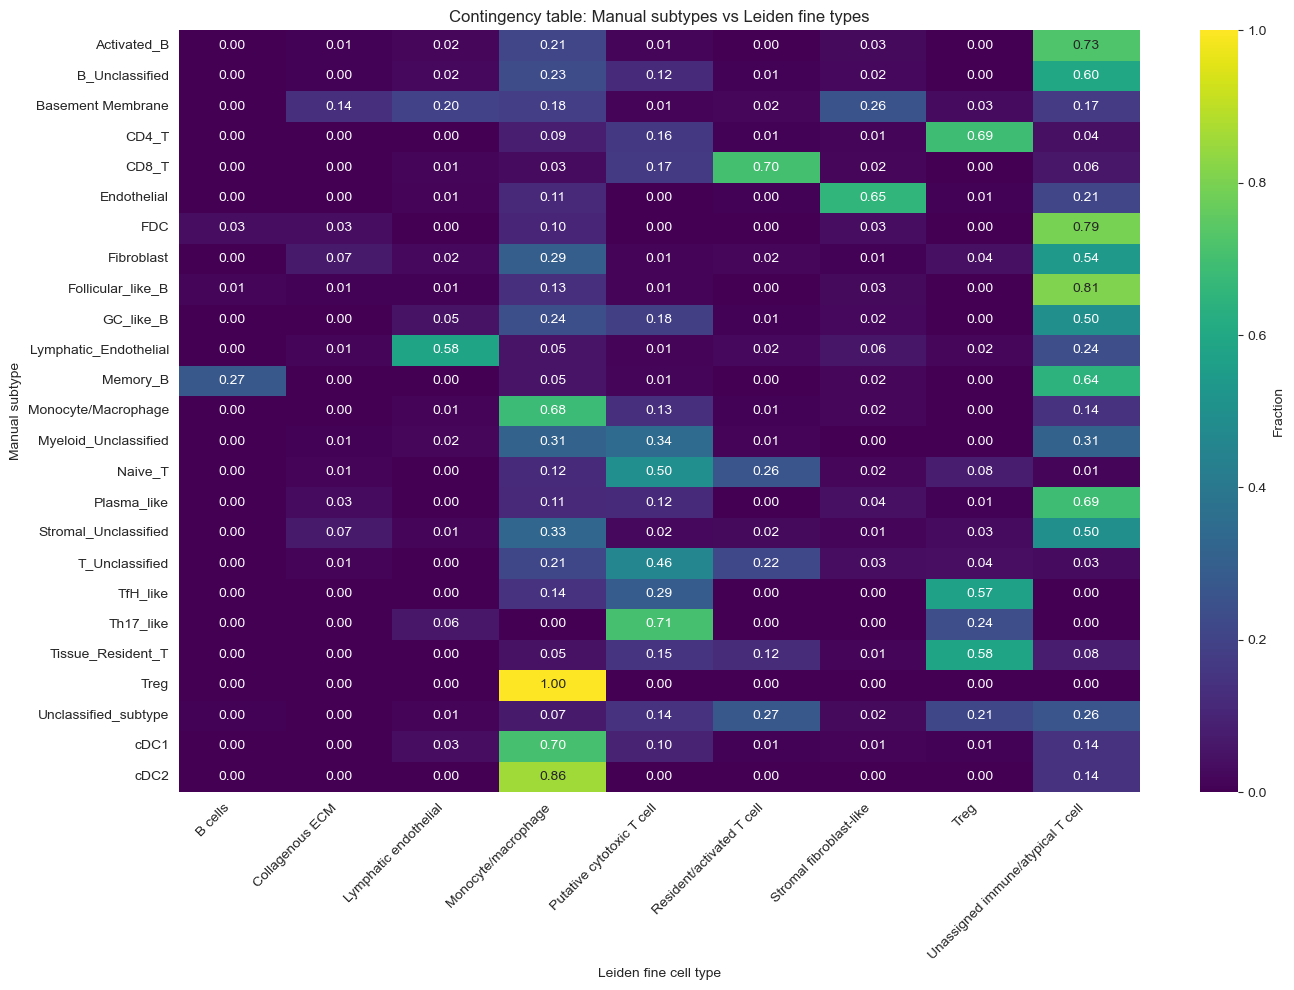

In [88]:
# Build a confusion matrix/contingency table of overlap between fine cell types
conf_mat = pd.crosstab(
    adata.obs['subtype'],
    adata.obs['leiden_celltype_fine'],
    normalize='index'  # optional: proportion per manual subtype
)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(14,10))
sns.heatmap(conf_mat, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Fraction'})
plt.title('Contingency table: Manual subtypes vs Leiden fine types')
plt.ylabel('Manual subtype')
plt.xlabel('Leiden fine cell type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

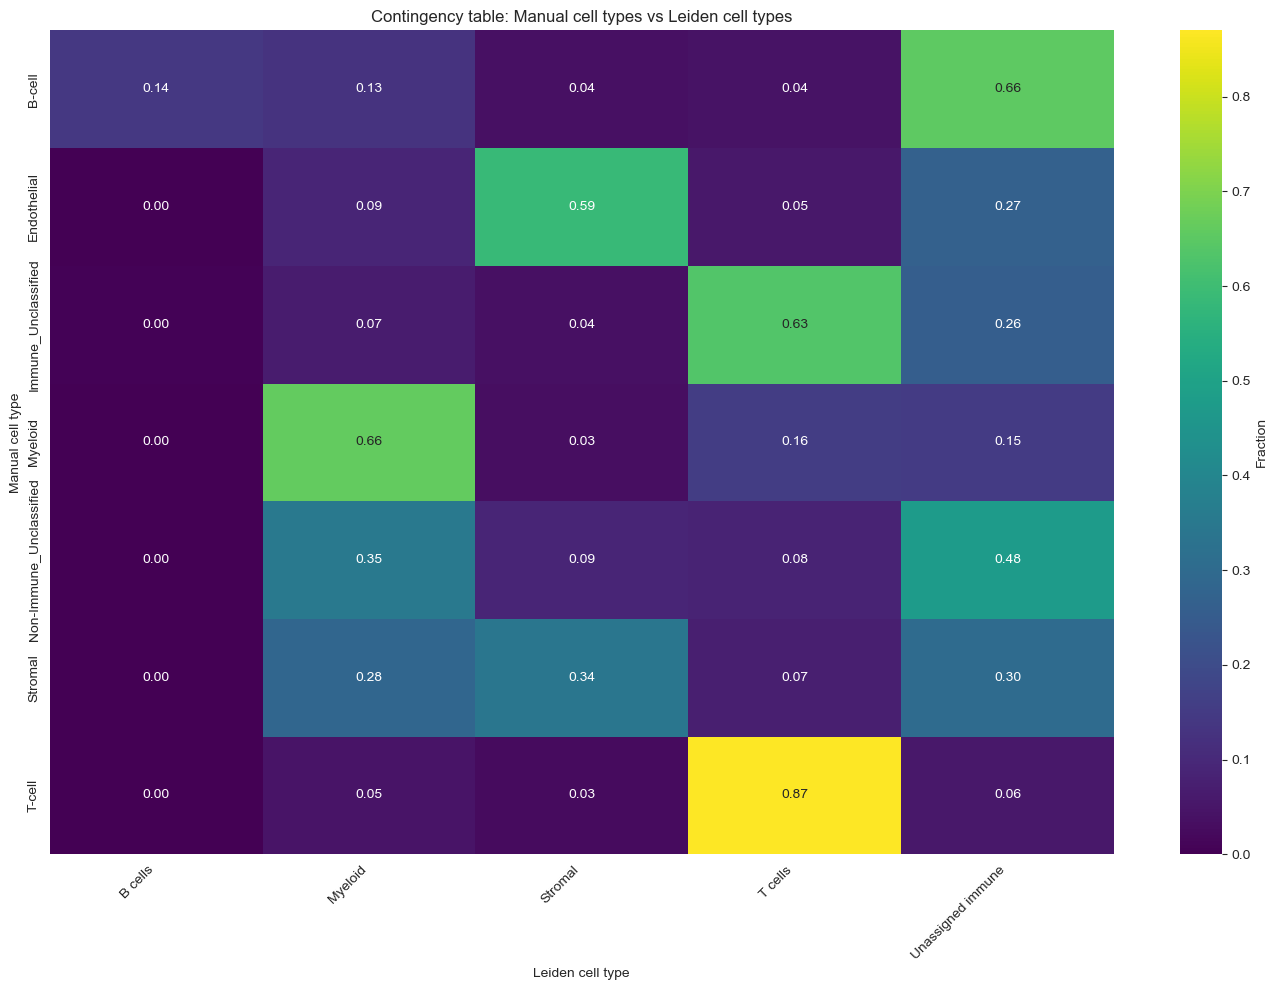

In [89]:
# Build a confusion matrix/contingency table of overlap between broad cell types
conf_mat = pd.crosstab(
    adata.obs['type'],
    adata.obs['leiden_celltype_major'],
    normalize='index'  # optional: proportion per manual subtype
)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(14,10))
sns.heatmap(conf_mat, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Fraction'})
plt.title('Contingency table: Manual cell types vs Leiden cell types')
plt.ylabel('Manual cell type')
plt.xlabel('Leiden cell type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Pearson correlation between Leiden-based and GMM-based annotations**

Compares patterns of abundance across cells or clusters. Interpret as an agreement in where the cell types live across clusters. "Do clusters enriched for “T-cell” manually also enrich “T cells” by Leiden?" or "Does the fraction of a manual cell type vary in the same pattern across Leiden clusters?"

High r means agreement in where these cell types live, 0 means unrelated, negative means mutual exclusiveness in assignment. Note that this is a linear correlation method which may not be well suited for this categorical cell type data.

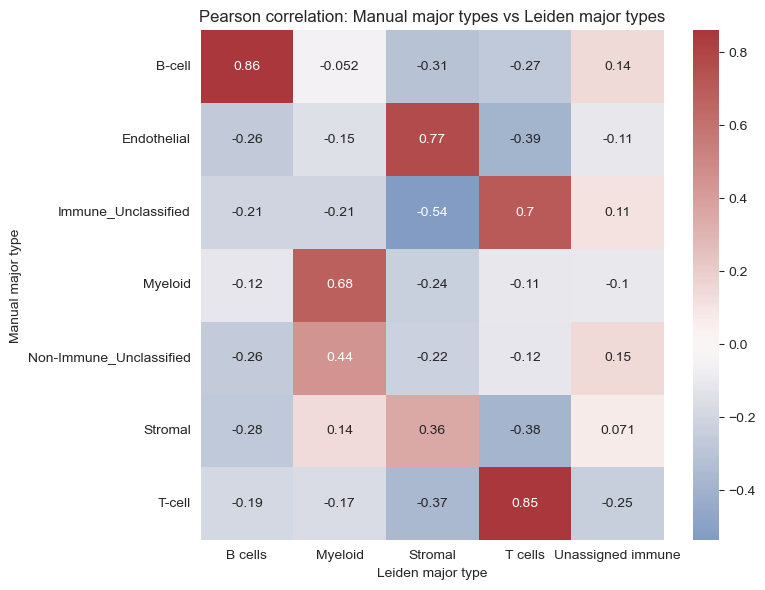

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Per-cluster compositions (as before)
manual_major = pd.crosstab(
    adata.obs['leiden'],
    adata.obs['type'],
    normalize='index'
)

leiden_major = pd.crosstab(
    adata.obs['leiden'],
    adata.obs['leiden_celltype_major'],
    normalize='index'
)

# Build correlation matrix explicitly
corr_major_full = pd.DataFrame(
    index=manual_major.columns,
    columns=leiden_major.columns,
    dtype=float
)

for m in manual_major.columns:
    for l in leiden_major.columns:
        corr_major_full.loc[m, l] = manual_major[m].corr(leiden_major[l])


plt.figure(figsize=(8,6))
sns.heatmap(
    corr_major_full,
    annot=True,
    cmap='vlag',
    center=0
)
plt.title('Pearson correlation: Manual major types vs Leiden major types')
plt.ylabel('Manual major type')
plt.xlabel('Leiden major type')
plt.tight_layout()
plt.show()



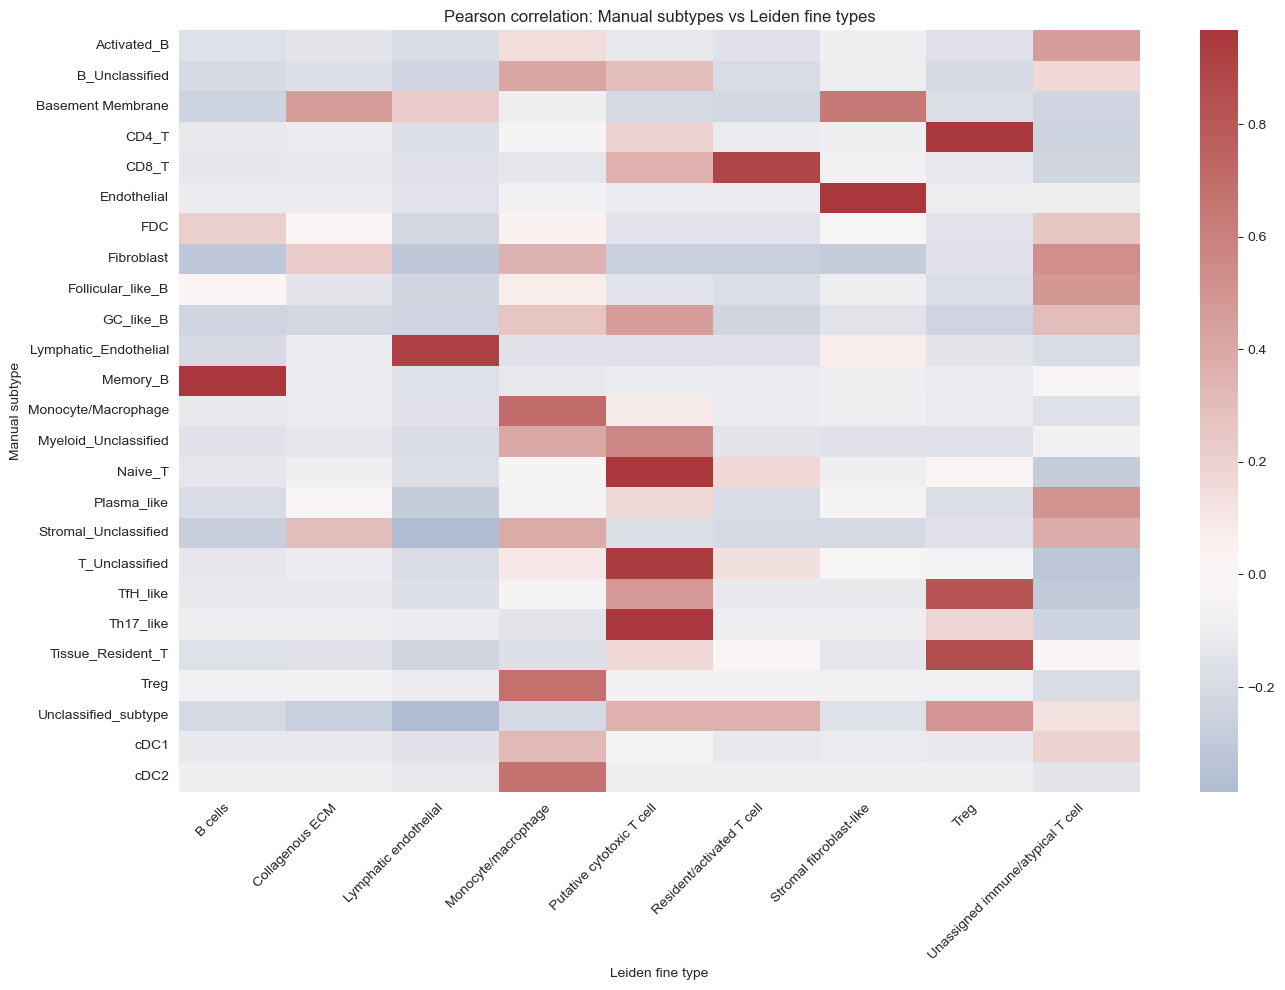

In [90]:
manual_fine = pd.crosstab(
    adata.obs['leiden'],
    adata.obs['subtype'],
    normalize='index'
)

leiden_fine = pd.crosstab(
    adata.obs['leiden'],
    adata.obs['leiden_celltype_fine'],
    normalize='index'
)

corr_fine = pd.DataFrame(
    index=manual_fine.columns,
    columns=leiden_fine.columns,
    dtype=float
)

for m in manual_fine.columns:
    for l in leiden_fine.columns:
        corr_fine.loc[m, l] = manual_fine[m].corr(leiden_fine[l])

# Plot
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_fine,
    cmap='vlag',
    center=0
)
plt.title('Pearson correlation: Manual subtypes vs Leiden fine types')
plt.ylabel('Manual subtype')
plt.xlabel('Leiden fine type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Chi-squared test**

Better suited for categorical data. Standardized residuals (observed - expected)/sqrt(expected) show which combinations are over- or under-represented.

Chi-squared statistic: 177725.94, p-value: 0.00e+00, degrees of freedom: 24


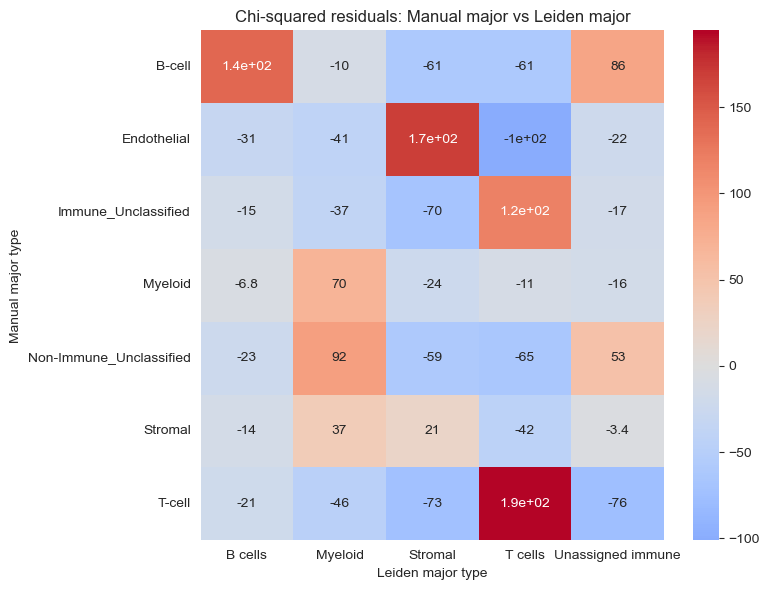

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Build contingency table: counts of cells
contingency_major = pd.crosstab(
    adata.obs['type'],
    adata.obs['leiden_celltype_major']
)

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_major)
print(f"Chi-squared statistic: {chi2:.2f}, p-value: {p:.2e}, degrees of freedom: {dof}")

# Optional: visualize observed vs expected as a heatmap (residuals)
residuals = (contingency_major - expected) / expected**0.5  # standardized residuals

plt.figure(figsize=(8,6))
sns.heatmap(residuals, annot=True, cmap='coolwarm', center=0)
plt.title('Chi-squared residuals: Manual major vs Leiden major')
plt.ylabel('Manual major type')
plt.xlabel('Leiden major type')
plt.tight_layout()
plt.show()


Chi-squared statistic: 316634.45, p-value: 0.00e+00, degrees of freedom: 192


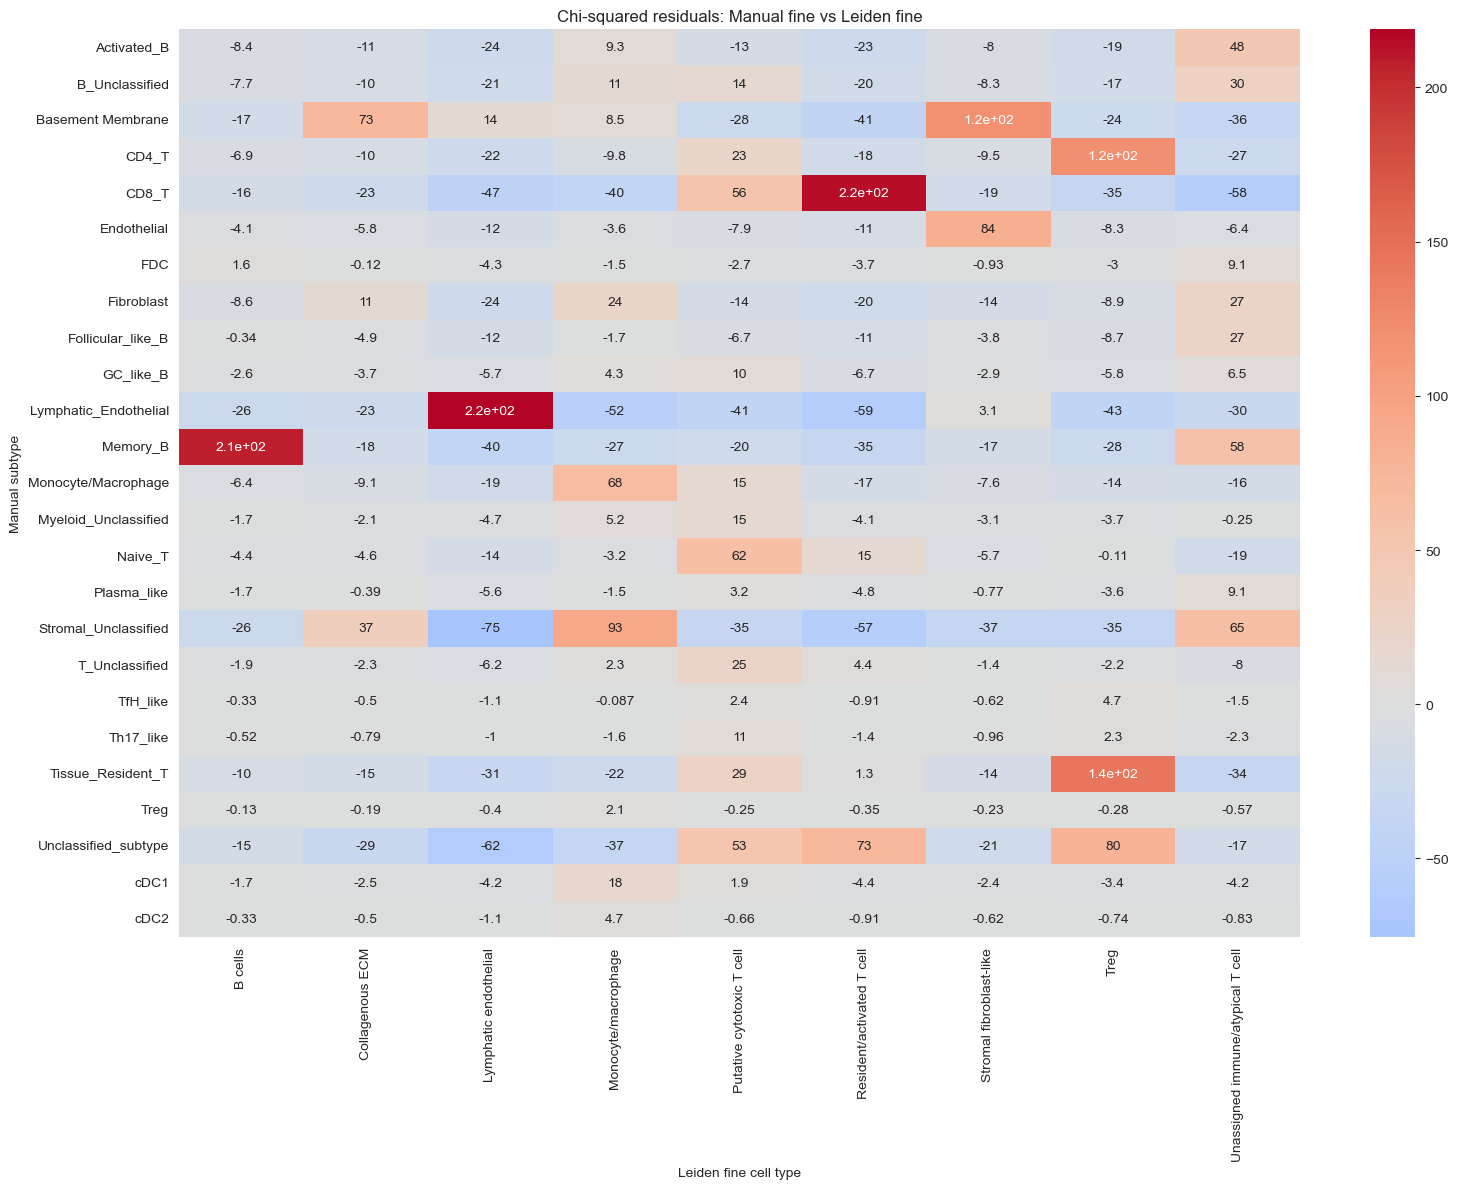

In [94]:
# Build contingency table: counts of cells
contingency_fine = pd.crosstab(
    adata.obs['subtype'],
    adata.obs['leiden_celltype_fine']
)

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_fine)
print(f"Chi-squared statistic: {chi2:.2f}, p-value: {p:.2e}, degrees of freedom: {dof}")

# Optional: visualize observed vs expected as a heatmap (residuals)
residuals = (contingency_fine - expected) / expected**0.5  # standardized residuals

plt.figure(figsize=(16,12))
sns.heatmap(residuals, annot=True, cmap='coolwarm', center=0)
plt.title('Chi-squared residuals: Manual fine vs Leiden fine')
plt.ylabel('Manual subtype')
plt.xlabel('Leiden fine cell type')
plt.tight_layout()
plt.show()
